In [1]:
import numpy as np
from numpy import ndarray, int64
import torch

Firstly, we import the data from the data folder. For the task 1 we only want the first question, so we only take the labels of the first question. 

In [2]:
import os
from pathlib import Path
from galaxyzoo.data import load_data
import pandas

img_path = Path("data/images")
labels_path = Path("data/labels.csv")

image_paths, labels_reg = load_data(img_path, labels_path, task="task3")

labels_reg.shape

(61578, 9)

## Preprocessing
Firstly, we will split the data into train, validation and test sets. 

In [3]:
from sklearn.model_selection import train_test_split

train_images, temp_images, train_labels, temp_labels = train_test_split(
    image_paths,
    labels_reg,
    test_size=0.3,
    random_state=42
)

val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images,
    temp_labels,
    test_size=0.5,
    random_state=42
)

print(f'Training size: {len(train_labels)} ({len(train_labels)/len(labels_reg)*100:.0f}%)')
print(f'Validation size: {len(val_labels)} ({len(val_labels)/len(labels_reg)*100:.0f}%)')
print(f'Test size: {len(test_labels)} ({len(test_labels)/len(labels_reg)*100:.0f}%)')

Training size: 43104 (70%)
Validation size: 9237 (15%)
Test size: 9237 (15%)


Next, we have to create a dataset for each set. We will use a different transformation for the training set, to increase the performance. 

In [4]:
from torchvision import transforms
from galaxyzoo.data import GalaxiesDataset

dim_pixels = 128
train_transform = transforms.Compose([
    transforms.CenterCrop(220), #cropping the image to zoom the galaxy
    transforms.Resize((dim_pixels, dim_pixels)),
    transforms.RandomHorizontalFlip(), #random rotation to improve the model
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(), #Normalize
])

validation_test_transform = transforms.Compose([
    transforms.CenterCrop(220), #cropping the image to zoom the galaxy
    transforms.Resize((dim_pixels, dim_pixels)),
    transforms.ToTensor(), #Normalize
])

train_dataset = GalaxiesDataset(train_images, train_labels, 
                                transform=train_transform, task="regression") #difference between class and reg
validation_dataset = GalaxiesDataset(val_images, val_labels, 
                                     transform=validation_test_transform, task="regression")
test_dataset = GalaxiesDataset(test_images, test_labels, 
                               transform=validation_test_transform, task="regression")

We plot the counts of every answer and also they weighted answer to validate the weights used. 

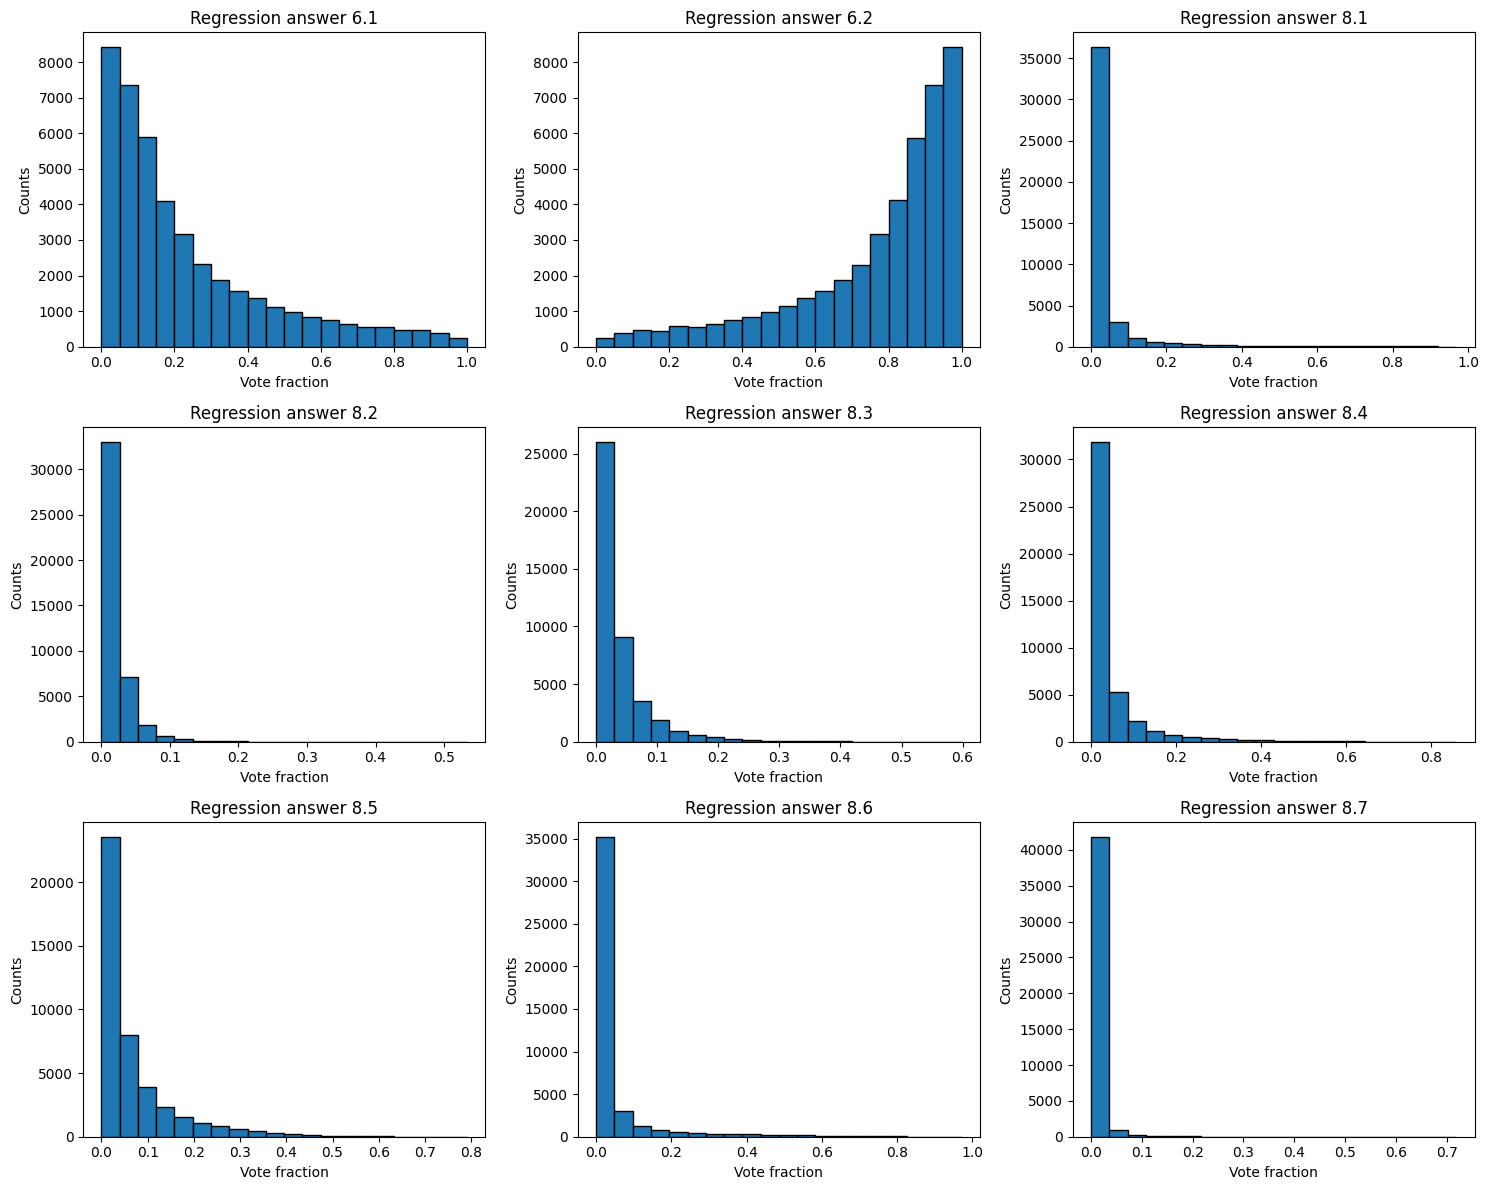

In [5]:
import matplotlib.pyplot as plt

labels_tensor = torch.tensor(train_labels)
bins = 20

#plot the figure
fig,axs = plt.subplots(3,3,figsize=(15,12))
axs = axs.flatten()
titles = ["6.1", "6.2", "8.1", "8.2", "8.3", "8.4", "8.5", "8.6", "8.7"]

for n in range(9):
    axs[n].hist(labels_tensor[:,n], edgecolor='k', bins=bins)
    axs[n].set_xlabel("Vote fraction")
    axs[n].set_ylabel("Counts")
    axs[n].set_title(f"Regression answer {titles[n]}")

fig.tight_layout()

Next, we will transform the dataset to dataloader of training, validation and test data. 

In [6]:
from torch.utils.data import DataLoader

batch_size=128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Training and fitting
After the preprocessing, we just need to specify the parameters of the model and fit the data. 

In [7]:
from torch import nn
from torch.optim import AdamW
from galaxyzoo.cnn import CNN
from galaxyzoo.training_utils import fit

in_channels = 3 #RGB
out_channels = 9 #9 answers

cnn_model = CNN(
    in_channels=in_channels,
    out_channels=out_channels,
    input_shape=(dim_pixels, dim_pixels),
    hidden_channels=16,
    final_hidden_channels=64,
    activation="relu",
    task="regression"
)

cnn_optimizer = AdamW(cnn_model.parameters(), lr=5e-4, weight_decay=1e-4)
loss_function = nn.MSELoss()
epochs = 10

train_losses, val_losses, _, _ = fit(
    epochs=epochs,
    loss_function=loss_function,
    model=cnn_model,
    optimizer=cnn_optimizer,
    train_loader=train_loader,
    validation_loader=validation_loader,
    include_accuracy=False, #not needed for regression
)

----------------------------------------
| Epoch 1                              |
| Train loss: 0.02068863326866036      |
| Validation loss: 0.01552728657317284 |
----------------------------------------
-----------------------------------------
| Epoch 2                               |
| Train loss: 0.014330747338337961      |
| Validation loss: 0.013990025807886499 |
-----------------------------------------
-----------------------------------------
| Epoch 3                               |
| Train loss: 0.013384407958242412      |
| Validation loss: 0.013393919927718705 |
-----------------------------------------
-----------------------------------------
| Epoch 4                               |
| Train loss: 0.013106280479038505      |
| Validation loss: 0.013304555610026398 |
-----------------------------------------
----------------------------------------
| Epoch 5                              |
| Train loss: 0.012833759465008886     |
| Validation loss: 0.01315420795844434 |
-

It is more useful to see the loss and the accuracy in a plot. 

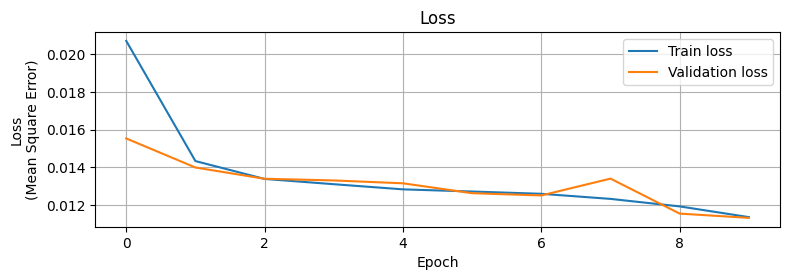

In [8]:
#plot the figure
fig = plt.figure()
fig.set_figheight(5)
fig.set_figwidth(8)

ax1 = plt.subplot(2,1,1)
ax1.plot(train_losses, label="Train loss")
ax1.plot(val_losses, label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss\n(Mean Square Error)")
ax1.set_title("Loss")
ax1.legend()
ax1.grid()

plt.tight_layout()

## Evaluation
Finally, we will evaluate the model with the test data. We will compute the confusion matrix and the ROC curves. 

In [9]:
labels_test = []
labels_preds = []

cnn_model.eval()

with torch.no_grad():

    for imgs, labels in test_loader:

        outputs = cnn_model(imgs)

        labels_test.extend(labels.cpu().numpy())
        labels_preds.extend(outputs.cpu().numpy())
    
    labels_test = np.array(labels_test)
    labels_preds = np.array(labels_preds)

In [10]:
from sklearn.metrics import mean_absolute_error

mae = []
for n in range(9):
    mae.append(
        mean_absolute_error(labels_test[:,n],labels_preds[:,n])
    )

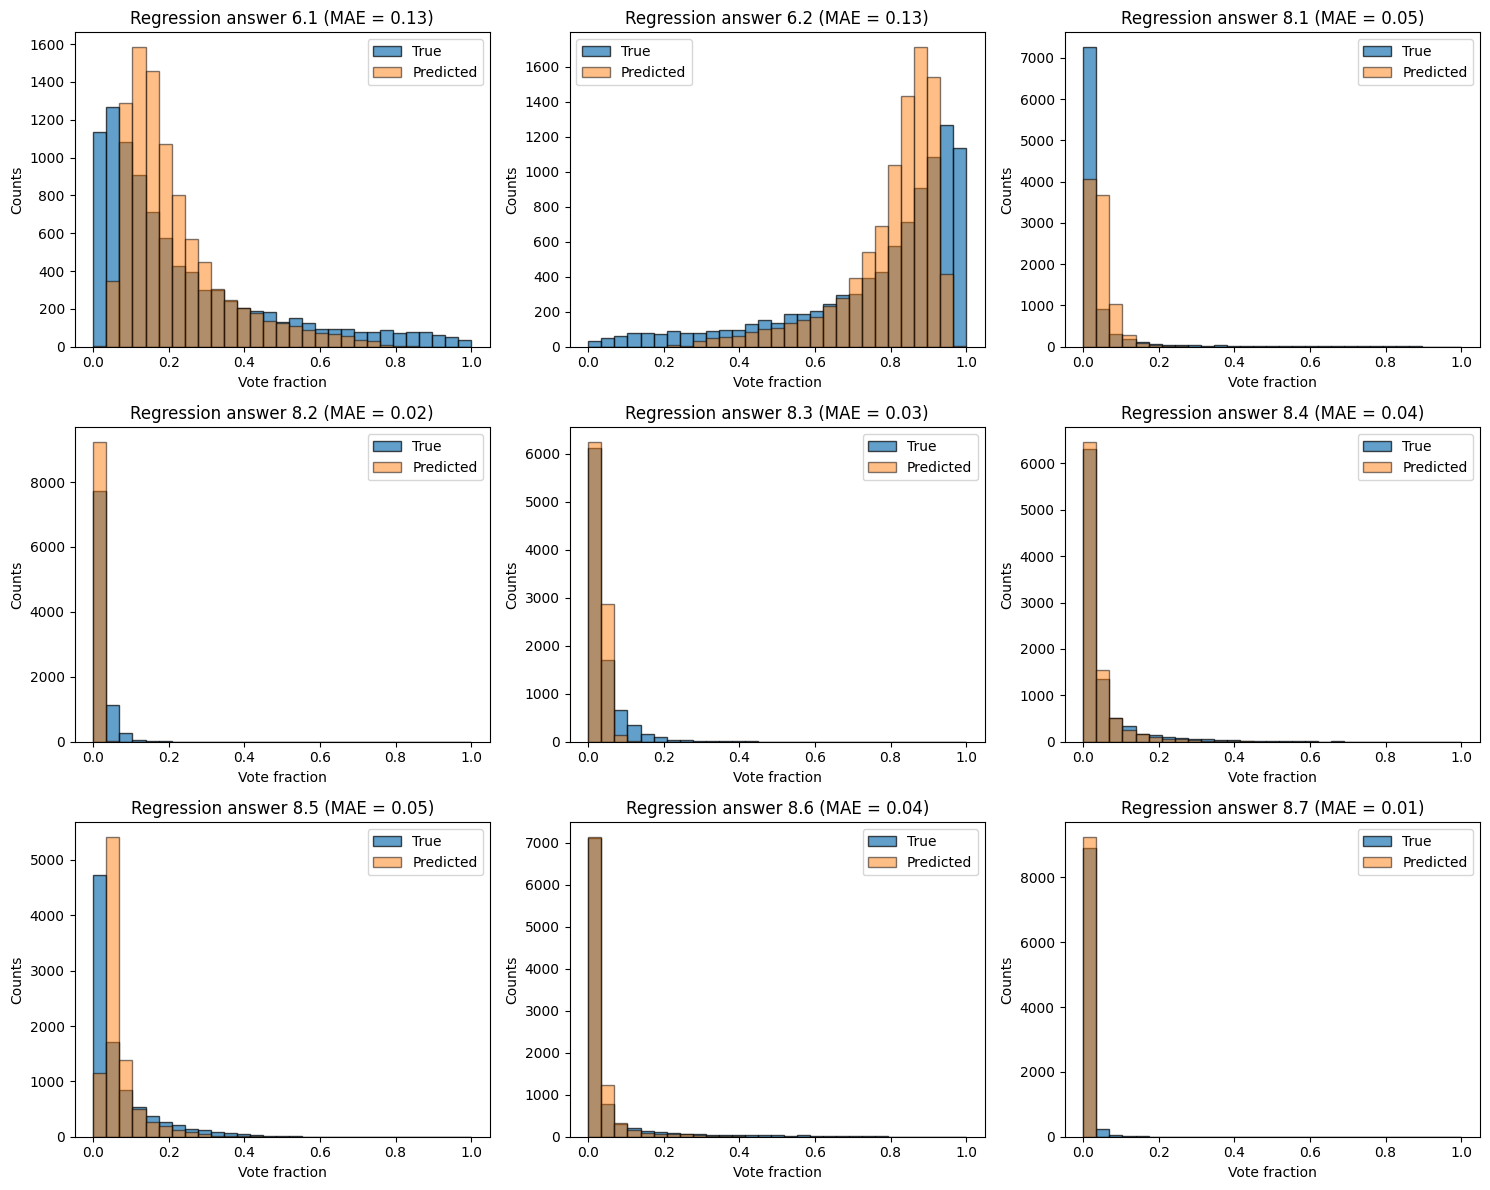

In [11]:
bins = np.linspace(0, 1, 30)

#plot the figure
fig,axs = plt.subplots(3,3,figsize=(15,12))
axs = axs.flatten()
titles = ["6.1", "6.2", "8.1", "8.2", "8.3", "8.4", "8.5", "8.6", "8.7"]

for n in range(9):
    axs[n].hist(labels_test[:,n], edgecolor='k', bins=bins, alpha=0.7, label='True')
    axs[n].hist(labels_preds[:,n], edgecolor='k', bins=bins, alpha=0.5, label='Predicted')
    axs[n].set_xlabel("Vote fraction")
    axs[n].set_ylabel("Counts")
    axs[n].set_title(f"Regression answer {titles[n]} (MAE = {mae[n]:0.2f})")
    axs[n].legend()

fig.tight_layout()

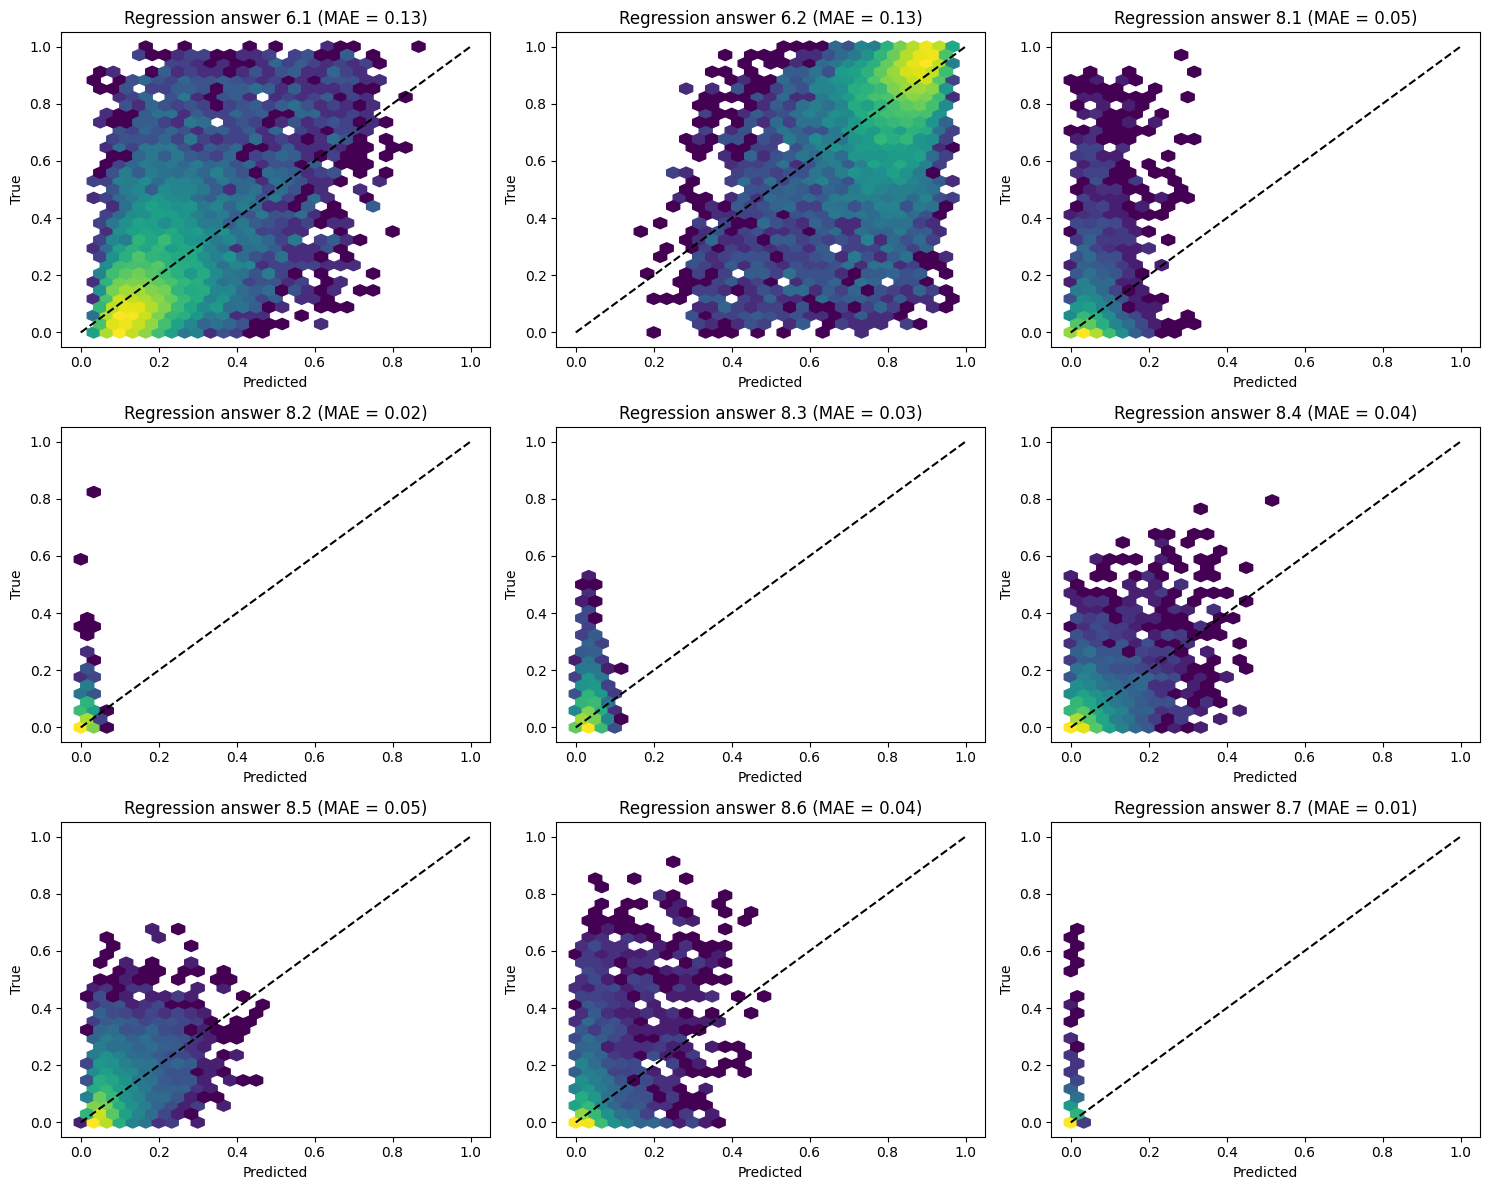

In [12]:
from matplotlib.colors import LogNorm

cmap = plt.cm.viridis
cmap.set_under(cmap(0))

#plot the figure
fig,axs = plt.subplots(3,3,figsize=(15,12))
axs = axs.flatten()
titles = ["6.1", "6.2", "8.1", "8.2", "8.3", "8.4", "8.5", "8.6", "8.7"]

for n in range(9):
    axs[n].hexbin(labels_preds[:,n],labels_test[:,n],
                  gridsize=30, bins='log', extent=(0,1,0,1))
    axs[n].plot([0,1],[0,1], color='k', linestyle='--')
    axs[n].set_xlabel("Predicted")
    axs[n].set_ylabel("True")
    axs[n].set_title(f"Regression answer {titles[n]} (MAE = {mae[n]:0.2f})")

fig.tight_layout()